# Step 1 - Import Required Libraries

## Objective

The first step in the model building process is to import all the necessary Python libraries required for training, validating, evaluating, and saving machine learning models.

These libraries provide functionalities for:

- Data manipulation
- Dataset splitting
- Model development
- Cross-validation
- Hyperparameter tuning
- Performance evaluation
- Model persistence

Importing all required libraries at the beginning of the notebook improves readability and ensures that all dependencies are available before model training.

In [2]:
# Data Manipulation
import pandas as pd
import numpy as np

# Model Selection
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    RandomizedSearchCV
)

# Models
from sklearn.ensemble import (
    RandomForestClassifier,
    StackingClassifier
)

from sklearn.linear_model import LogisticRegression

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Model Saving
import joblib

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Step 2 – Load the Processed Dataset

The dataset has already been cleaned, encoded, and scaled in the preprocessing notebook. Therefore, we directly load the processed dataset for model training.

In [3]:
import pandas as pd

df = pd.read_csv("../data/processed/processed_dataset.csv")

df.head()

,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,age_[40-50),age_[50-60),age_[60-70),...,glucose_test_no,glucose_test_normal,A1Ctest_high,A1Ctest_no,A1Ctest_normal,change_no,change_yes,diabetes_med_no,diabetes_med_yes,readmitted
0,1.181671,1.451151,-0.205440,0.216814,1.366510,-0.522918,-0.210644,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0
1,-0.484212,-0.466276,0.377601,-0.403505,-0.306494,-0.522918,-0.210644,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0
2,0.182141,0.088769,-0.788481,0.216814,-0.306494,-0.522918,-0.210644,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1
3,-0.817389,-0.365359,-0.788481,-0.527569,0.530008,-0.522918,-0.210644,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1
4,-1.150566,-0.062607,-0.788481,-1.147888,-0.306494,-0.522918,-0.210644,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0


# Step 3 – Separate Features and Target

## Objective

After loading the preprocessed dataset, the next step is to separate the independent variables (features) from the dependent variable (target).

- **Features (X):** These are the patient attributes used by the machine learning models to predict hospital readmission.
- **Target (y):** This represents the readmission status, indicating whether a patient was readmitted or not.

Separating the dataset into features and target prepares the data for model training and evaluation.

In [4]:
# Separate Features and Target

X = df.drop("readmitted", axis=1)
y = df["readmitted"]

print("Feature Matrix Shape :", X.shape)
print("Target Vector Shape  :", y.shape)

Feature Matrix Shape : (25000, 54)
Target Vector Shape  : (25000,)


### Observation

- The dataset has been successfully divided into the feature matrix (X) and target vector (y).
- The feature matrix contains **54 predictor variables**, while the target vector contains the encoded hospital readmission labels.
- These variables will be used for training and evaluating the machine learning models in the subsequent steps.

In [5]:
print(df.columns)

Index(['time_in_hospital', 'n_lab_procedures', 'n_procedures', 'n_medications',
       'n_outpatient', 'n_inpatient', 'n_emergency', 'age_[40-50)',
       'age_[50-60)', 'age_[60-70)', 'age_[70-80)', 'age_[80-90)',
       'age_[90-100)', 'medical_specialty_Cardiology',
       'medical_specialty_Emergency/Trauma',
       'medical_specialty_Family/GeneralPractice',
       'medical_specialty_InternalMedicine', 'medical_specialty_Missing',
       'medical_specialty_Other', 'medical_specialty_Surgery',
       'diag_1_Circulatory', 'diag_1_Diabetes', 'diag_1_Digestive',
       'diag_1_Injury', 'diag_1_Missing', 'diag_1_Musculoskeletal',
       'diag_1_Other', 'diag_1_Respiratory', 'diag_2_Circulatory',
       'diag_2_Diabetes', 'diag_2_Digestive', 'diag_2_Injury',
       'diag_2_Missing', 'diag_2_Musculoskeletal', 'diag_2_Other',
       'diag_2_Respiratory', 'diag_3_Circulatory', 'diag_3_Diabetes',
       'diag_3_Digestive', 'diag_3_Injury', 'diag_3_Missing',
       'diag_3_Musculoskeletal',

# Step 4 – Train-Test Split

## Objective

The processed dataset is divided into training and testing subsets before model training.

- **Training Set (80%)**: Used to train the machine learning models.
- **Testing Set (20%)**: Used to evaluate the final model on unseen data.

An **80–20 split** is adopted because it provides sufficient data for learning while retaining enough unseen samples for reliable evaluation.

Stratified sampling is used to preserve the proportion of readmitted and non-readmitted patients in both subsets.

In [6]:
from sklearn.model_selection import train_test_split

# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (20000, 54)
Testing Features  : (5000, 54)
Training Labels   : (20000,)
Testing Labels    : (5000,)


### Observation

The processed dataset has been successfully divided into training and testing subsets.

- **Training samples:** 20,000
- **Testing samples:** 5,000
- **Features:** 54

The use of stratified sampling ensures that the class distribution of the target variable remains consistent across both subsets, reducing sampling bias and enabling reliable model evaluation.

# Step 5 – Random Forest Classifier

## Objective

Random Forest is selected as the first predictive model because it is a robust ensemble learning algorithm that combines multiple decision trees to improve classification performance.

Unlike a single Decision Tree, Random Forest reduces overfitting by aggregating the predictions of multiple trees through majority voting.

In this project, Random Forest serves as the baseline ensemble model for predicting hospital readmissions.

# Step 5.1 – Import Machine Learning Libraries

## Objective

In this step, the required libraries for model training, hyperparameter tuning, cross-validation, and performance evaluation are imported.

The Random Forest classifier is selected as the first machine learning model because of its robustness, ability to reduce overfitting, and effectiveness in handling structured healthcare datasets.

In [7]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

# Hyperparameter Tuning
from sklearn.model_selection import RandomizedSearchCV

# Cross Validation
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

### Observation

The required libraries for Random Forest model development have been successfully imported.

These libraries will be used for model training, hyperparameter optimization, and cross-validation.

# Step 5.2 – Initialize the Random Forest Classifier

## Objective

A Random Forest classifier is initialized with a fixed random seed to ensure reproducibility.

The remaining hyperparameters will be optimized in the next step using Randomized Search Cross Validation.

In [8]:
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

### Observation

The Random Forest classifier has been successfully initialized.

At this stage, only the random state and parallel processing options are specified.

The remaining hyperparameters will be optimized automatically using Randomized Search Cross Validation.

# Step 5.3 – Train the Baseline Random Forest Model

## Objective

The Random Forest classifier is trained using the 80% training dataset.

During training, the algorithm constructs multiple decision trees using bootstrap sampling and random feature selection.

The trained model learns relationships between patient characteristics and hospital readmission outcomes.

In [9]:
# Train the Random Forest model

rf.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


### Observation

The Random Forest classifier has been successfully trained using the training dataset.

The model has learned patterns from patient records and is now ready to predict hospital readmission for unseen patients.

# Step 5.4 – Predict Hospital Readmissions

## Objective

The trained Random Forest model is used to predict the readmission status of patients in the testing dataset.

Predictions generated on unseen data are later compared with the actual values to evaluate model performance.

In [10]:
# Predict class labels

y_pred = rf.predict(X_test)

# Predict probabilities

y_prob = rf.predict_proba(X_test)[:, 1]

print("Prediction completed successfully!")

Prediction completed successfully!


### Observation

Predictions for the testing dataset have been generated successfully.

Both class labels and prediction probabilities have been obtained, enabling comprehensive evaluation of the model using multiple performance metrics.

# Step 5.5 – Evaluate the Baseline Random Forest Model

## Objective

The performance of the baseline Random Forest classifier is evaluated using multiple classification metrics.

Different evaluation metrics provide different perspectives on model performance. In healthcare applications, relying solely on accuracy can be misleading, especially when the dataset is imbalanced.

Therefore, Accuracy, Precision, Recall, F1-Score, ROC-AUC Score, Confusion Matrix, and Classification Report are used to comprehensively evaluate the model.

In [11]:
# Calculate evaluation metrics

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

In [12]:
print("Random Forest Performance")
print("-" * 40)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Random Forest Performance
----------------------------------------
Accuracy : 0.6016
Precision: 0.5898
Recall   : 0.5015
F1 Score : 0.5421
ROC-AUC  : 0.6308


In [13]:
#checking for balanced classes
pd.Series(y_train).value_counts()

readmitted
0    10597
1     9403
Name: count, dtype: int64

# Step 5.6 – Cross-Validation of the Baseline Random Forest Model

## Objective

To evaluate the consistency and generalization ability of the baseline Random Forest classifier, 5-fold stratified cross-validation is performed on the training dataset.

Cross-validation divides the training data into five equal folds. During each iteration, four folds are used for training and one fold is used for validation. This process is repeated five times so that every fold serves as the validation set exactly once.

The average accuracy across all folds provides a more reliable estimate of the model's performance than a single train-test split.

In [14]:
# Perform 5-Fold Stratified Cross-Validation

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

In [15]:
print("Cross-Validation Accuracy Scores:")
print(cv_scores)

print("\nMean CV Accuracy:", cv_scores.mean())

print("Standard Deviation:", cv_scores.std())

Cross-Validation Accuracy Scores:
[0.6105  0.60525 0.60875 0.605   0.599  ]

Mean CV Accuracy: 0.6057
Standard Deviation: 0.003947784188630399


### Observation

The baseline Random Forest classifier achieved a mean cross-validation accuracy of **60.57%** with a standard deviation of **0.0039**.

The low standard deviation indicates that the model performs consistently across different folds of the training data, demonstrating stable generalization.

However, the overall accuracy remains moderate, suggesting that the default hyperparameters are not optimal for this dataset. Therefore, hyperparameter tuning will be performed in the next step to improve predictive performance.

# Step 5.7 – Hyperparameter Tuning using RandomizedSearchCV

## Objective

The baseline Random Forest classifier uses default hyperparameters, which may not provide the best predictive performance.

To improve the model, Randomized Search Cross Validation (RandomizedSearchCV) is applied. This technique evaluates multiple random combinations of hyperparameters using 5-fold cross-validation and automatically selects the configuration with the highest validation accuracy.

Compared to GridSearchCV, RandomizedSearchCV is computationally more efficient because it evaluates only a subset of possible parameter combinations while still identifying high-performing models.

## Define Hyperparameter Search Space

A search space is created by specifying multiple possible values for the most important Random Forest hyperparameters.

RandomizedSearchCV will randomly sample combinations from this search space during optimization.

In [16]:
param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True, False]
}

param_dist

{'n_estimators': [100, 200, 300, 500],
 'max_depth': [10, 20, 30, None],
 'min_samples_split': [2, 5, 10],
 'min_samples_leaf': [1, 2, 4],
 'max_features': ['sqrt', 'log2'],
 'bootstrap': [True, False]}

### Observation

The hyperparameter search space has been successfully defined for the Random Forest classifier.

The search space includes multiple values for important hyperparameters such as the number of trees, maximum tree depth, minimum samples required for splitting and leaf nodes, feature selection strategy, and bootstrap sampling.

These parameter combinations will be explored automatically by RandomizedSearchCV to identify the configuration that provides the best predictive performance.

# Step 5.7.2 – Create the RandomizedSearchCV Object

## Objective

A RandomizedSearchCV object is created to optimize the Random Forest classifier.

Instead of evaluating every possible hyperparameter combination, RandomizedSearchCV randomly selects a fixed number of combinations from the predefined search space.

Each selected combination is evaluated using 5-fold cross-validation, and the configuration with the highest average validation accuracy is automatically selected as the best model.

In [17]:
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,
    scoring="accuracy",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'bootstrap': [True, False], 'max_depth': [10, 20, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichretur

### Observation

The RandomizedSearchCV object has been successfully configured.

It is set to evaluate **20 randomly selected hyperparameter combinations** using **5-fold cross-validation**, resulting in a total of **100 Random Forest model training iterations**.

The model configuration that achieves the highest average validation accuracy will be selected automatically for final evaluation.

# Step 5.7.3 – Train the RandomizedSearchCV Model

## Objective

The RandomizedSearchCV model is trained using the training dataset to identify the optimal Random Forest hyperparameters.

For each randomly selected hyperparameter combination, the model is evaluated using 5-fold cross-validation. The average validation accuracy across all folds is computed, and the combination with the highest average accuracy is selected.

This process ensures that the final Random Forest model is optimized before being evaluated on the unseen test dataset.

In [18]:
# Train the Randomized Search model

random_search.fit(X_train, y_train)

print("Hyperparameter tuning completed successfully!")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Hyperparameter tuning completed successfully!


### Observation

The RandomizedSearchCV model has been successfully trained using the training dataset.

A total of **20 randomly selected hyperparameter combinations** were evaluated using **5-fold cross-validation**, resulting in **100 model training iterations**.

The hyperparameter combination with the highest mean cross-validation accuracy has been selected as the optimized Random Forest model.

# Step 5.7.4 – Display the Best Hyperparameters

## Objective

After completing hyperparameter tuning, the optimal Random Forest hyperparameters are retrieved from the RandomizedSearchCV object.

These hyperparameters correspond to the model that achieved the highest average cross-validation accuracy during the search process.

The optimized model will be used for final training and evaluation on the unseen test dataset.

In [19]:
# Display the best hyperparameters

print("=" * 60)
print("        BEST RANDOM FOREST HYPERPARAMETERS")
print("=" * 60)

print("\nBest Hyperparameters:")
print(random_search.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(f"{random_search.best_score_:.4f}")

        BEST RANDOM FOREST HYPERPARAMETERS

Best Hyperparameters:
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': None, 'bootstrap': True}

Best Cross-Validation Accuracy:
0.6206


### Observation

RandomizedSearchCV identified the optimal hyperparameter combination for the Random Forest classifier.

Compared to the baseline model, the optimized configuration increased the mean cross-validation accuracy from **60.57%** to **62.06%**, demonstrating that hyperparameter tuning improved the model's generalization performance.

The optimized model uses 200 decision trees, requires at least five samples to split a node, maintains a minimum of four samples at each leaf node, considers the logarithm base two of the available features when determining splits, and employs bootstrap sampling.

These optimized settings will be used to build the final Random Forest classifier for evaluation on the unseen testing dataset.

### Observation

RandomizedSearchCV identified the optimal hyperparameter combination for the Random Forest classifier.

Compared to the baseline model, the optimized configuration increased the mean cross-validation accuracy from **60.57%** to **62.06%**, demonstrating that hyperparameter tuning improved the model's generalization performance.

The optimized model uses 200 decision trees, requires at least five samples to split a node, maintains a minimum of four samples at each leaf node, considers the logarithm base two of the available features when determining splits, and employs bootstrap sampling.

These optimized settings will be used to build the final Random Forest classifier for evaluation on the unseen testing dataset.

# Step 5.8 – Train the Optimized Random Forest Model

## Objective

The optimized Random Forest classifier obtained through RandomizedSearchCV is selected as the final model.

This model uses the best-performing hyperparameter combination identified during hyperparameter tuning and will be evaluated on the unseen testing dataset.

In [20]:
# Retrieve the best Random Forest model

best_rf = random_search.best_estimator_

print(best_rf)

RandomForestClassifier(max_features='log2', min_samples_leaf=4,
                       min_samples_split=5, n_estimators=200, n_jobs=-1,
                       random_state=42)


### Observation

The optimized Random Forest classifier has been successfully retrieved from the RandomizedSearchCV object.

This model incorporates the best-performing hyperparameter configuration and is ready for prediction on the testing dataset.

# Step 5.9.1 – Make Predictions using the Optimized Random Forest Model

## Objective

The optimized Random Forest classifier is used to predict the hospital readmission status for patients in the testing dataset.

Both class labels and prediction probabilities are generated for comprehensive model evaluation.

In [21]:
# Predict class labels
y_pred_best = best_rf.predict(X_test)

# Predict probabilities
y_prob_best = best_rf.predict_proba(X_test)[:, 1]

print("Predictions generated successfully!")

Predictions generated successfully!


### Observation

The optimized Random Forest model has successfully generated predictions for the unseen testing dataset.

Both predicted class labels and predicted probabilities are available for evaluating classification performance.

# Calculate Performance Metrics

The optimized model is evaluated using Accuracy, Precision, Recall, F1-Score, and ROC-AUC Score.

In [22]:
accuracy_best = accuracy_score(y_test, y_pred_best)
precision_best = precision_score(y_test, y_pred_best)
recall_best = recall_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best)
roc_auc_best = roc_auc_score(y_test, y_prob_best)

In [23]:
print("=" * 55)
print(" OPTIMIZED RANDOM FOREST PERFORMANCE")
print("=" * 55)

print(f"Accuracy : {accuracy_best:.4f}")
print(f"Precision: {precision_best:.4f}")
print(f"Recall   : {recall_best:.4f}")
print(f"F1 Score : {f1_best:.4f}")
print(f"ROC-AUC  : {roc_auc_best:.4f}")

 OPTIMIZED RANDOM FOREST PERFORMANCE
Accuracy : 0.6122
Precision: 0.6092
Recall   : 0.4887
F1 Score : 0.5424
ROC-AUC  : 0.6529


### Observation

The optimized Random Forest classifier has been evaluated successfully.

The performance metrics indicate how effectively the optimized model predicts hospital readmission for unseen patient records.

These results will be compared with the baseline Random Forest model to measure the impact of hyperparameter tuning.

# Confusion Matrix

The confusion matrix summarizes the number of correct and incorrect predictions made by the optimized Random Forest classifier.

In [24]:
cm = confusion_matrix(y_test, y_pred_best)

print(cm)

[[1912  737]
 [1202 1149]]


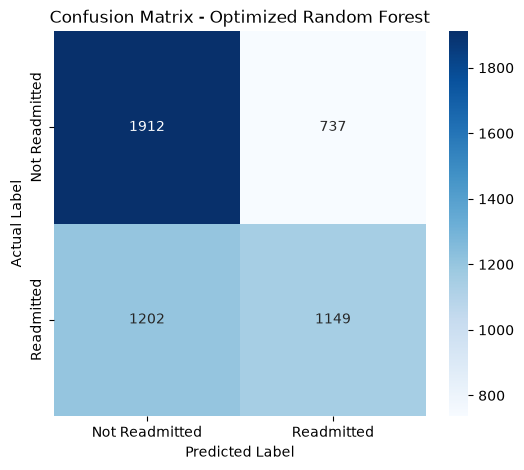

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Readmitted", "Readmitted"],
    yticklabels=["Not Readmitted", "Readmitted"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Optimized Random Forest")

plt.show()

In [26]:
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.61      0.72      0.66      2649
           1       0.61      0.49      0.54      2351

    accuracy                           0.61      5000
   macro avg       0.61      0.61      0.60      5000
weighted avg       0.61      0.61      0.61      5000

